In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Raw data path
DATA_PATH = "data/raw"

HELD_ASSETS = ['SPY', 'QQQ', 'JPM', 'XLI', 'JNJ', 'KO', 'NEE', 'IEF', 'GLD', 'XLE', 'UPS']

file_map = {
    'SPY': 'spy_us_d.csv',
    'QQQ': 'qqq_us_d.csv',
    'JPM': 'jpm_us_d.csv',
    'XLI': 'xli_us_d.csv',
    'JNJ': 'jnj_us_d.csv',
    'KO':  'ko_us_d.csv',
    'NEE': 'nee_us_d.csv',
    'IEF': 'ief_us_d.csv',
    'GLD': 'gld_us_d.csv',
    'XLE': 'xle_us_d.csv',
    'UPS': 'ups_us_d.csv',
}

In [2]:
# Load and clean each price series first
frames = {}

for ticker, fname in file_map.items():
    df = pd.read_csv(
        os.path.join(DATA_PATH, fname),
        parse_dates=['Date']
    )

    # Keep only needed columns
    df = df[['Date', 'Close']].copy()

    # Ensure numeric close
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

    # Sort and remove duplicate dates
    df = df.sort_values('Date')
    df = df.drop_duplicates(subset='Date', keep='last')

    # Remove invalid prices
    df = df[df['Close'] > 0]

    # Store as named series
    series = df.set_index('Date')['Close']
    series.name = ticker
    frames[ticker] = series

prices_raw = pd.DataFrame(frames)
prices_raw.index.name = 'Date'

print("Raw merged shape:", prices_raw.shape)
print("Raw date range:", prices_raw.index.min().date(), "->", prices_raw.index.max().date())
prices_raw.head(100)

Raw merged shape: (5356, 11)
Raw date range: 2005-01-03 -> 2026-04-17


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2005-01-03,NaN,33.8267,28.2246,NaN,44.5777,14.3330,NaN,NaN,NaN,NaN,59.9527
2005-01-04,NaN,33.2080,27.6930,NaN,44.4364,14.1324,NaN,NaN,NaN,NaN,59.1922
2005-01-05,NaN,33.0054,27.7481,NaN,44.4080,14.0708,NaN,NaN,NaN,NaN,59.0732
2005-01-06,NaN,32.8342,27.8974,NaN,44.5393,14.1843,NaN,NaN,NaN,NaN,59.0089
2005-01-07,NaN,33.0151,27.6842,NaN,44.3756,14.2019,NaN,NaN,NaN,NaN,58.8959
...,...,...,...,...,...,...,...,...,...,...,...
2005-05-19,92.0455,32.1212,26.0956,24.0376,47.7744,15.6133,7.17462,70.5440,41.98,12.0064,53.0127
2005-05-20,91.9098,32.2448,25.9984,24.0296,47.6244,15.5495,7.19707,70.5351,41.65,11.9164,52.8957
2005-05-23,92.4159,32.4153,25.8922,24.1951,47.6705,15.5183,7.19363,70.8569,41.62,12.1138,53.1200


In [3]:
# Diagnostic view before final cleaning
subset = prices_raw.loc['2005-02-25':'2026-04-17'].copy()

print("Subset shape before dropna:", subset.shape)
print("Subset date range:", subset.index.min().date(), "->", subset.index.max().date())

print("\nMissing values per asset:")
print(subset.isna().sum().sort_values())

complete_rows = subset.dropna(how='any')
print("\nComplete rows:", len(complete_rows))
print("Complete-date ratio:", round(len(complete_rows) / len(subset), 4))

missing_rows = subset[subset.isna().any(axis=1)]
print("\nRows with at least one missing value:", len(missing_rows))

missing_rows.head(10)

Subset shape before dropna: (5319, 11)
Subset date range: 2005-02-25 -> 2026-04-17

Missing values per asset:
QQQ    0
JPM    0
KO     0
JNJ    0
UPS    0
XLI    1
NEE    1
SPY    1
IEF    1
GLD    1
XLE    1
dtype: int64

Complete rows: 5318
Complete-date ratio: 0.9998

Rows with at least one missing value: 1


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2011-02-17,NaN,51.7353,34.4768,NaN,43.0831,22.2761,NaN,NaN,NaN,NaN,53.8385


In [4]:
# Final clean common price panel
prices = (
    prices_raw
    .loc['2005-02-25':'2026-04-17']
    .sort_index()
    .dropna(how='any')
)

print("Clean prices shape:", prices.shape)
print("Clean date range:", prices.index.min().date(), "->", prices.index.max().date())
print("Total missing values:", prices.isna().sum().sum())

prices.head()

Clean prices shape: (5318, 11)
Clean date range: 2005-02-25 -> 2026-04-17
Total missing values: 0


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2005-02-25,93.6948,32.2066,26.6536,24.4002,46.9331,14.8429,7.09458,69.6356,43.50,13.2739,54.4449
2005-02-28,93.0544,31.8690,26.3520,24.2585,46.4948,14.7687,7.06248,69.1842,43.52,13.1787,54.6564
2005-03-01,93.5386,32.2166,26.7420,24.3357,47.2391,14.9311,7.16349,69.0010,43.22,12.9226,54.6068
2005-03-02,93.4927,32.2066,26.6674,24.4081,47.4558,14.8518,7.05854,68.9930,43.25,13.1120,54.2479
2005-03-03,93.5301,31.9413,26.6832,24.4626,47.3048,14.8977,7.11180,68.9511,42.97,13.3284,54.4848


In [5]:
# Date gap check
date_gaps = prices.index.to_series().diff().value_counts().sort_index()

print(date_gaps.head(10))

Date
1 days    4161
2 days      53
3 days     960
4 days     141
5 days       2
Name: count, dtype: int64


In [6]:
# Final summary
summary = pd.DataFrame({
    'missing_before_cleaning': subset.isna().sum(),
    'non_null_after_cleaning': prices.notna().sum(),
})

summary.loc['TOTAL'] = [
    summary['missing_before_cleaning'].sum(),
    summary['non_null_after_cleaning'].sum()
]

summary

,missing_before_cleaning,non_null_after_cleaning
SPY,1,5318
QQQ,0,5318
JPM,0,5318
XLI,1,5318
JNJ,0,5318
KO,0,5318
NEE,1,5318
IEF,1,5318
GLD,1,5318
XLE,1,5318


In [7]:
missing_rows = subset[subset.isna().any(axis=1)]
missing_rows

,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2011-02-17,NaN,51.7353,34.4768,NaN,43.0831,22.2761,NaN,NaN,NaN,NaN,53.8385


In [8]:
big_gaps = prices.index.to_series().diff()
big_gaps = big_gaps[big_gaps > pd.Timedelta('4 days')]
print(big_gaps)

Date
2007-01-03   5 days
2012-10-31   5 days
Name: Date, dtype: timedelta64[us]


In [9]:
# Extreme return inspection
returns = prices.pct_change().dropna()

extreme_mask = returns.abs() > 0.30
extreme_counts = extreme_mask.sum()

print("Extreme daily moves (> 30%) per asset:")
print(extreme_counts)

extreme_rows = returns[extreme_mask.any(axis=1)]
extreme_rows

Extreme daily moves (> 30%) per asset:
SPY    0
QQQ    0
JPM    0
XLI    0
JNJ    0
KO     0
NEE    0
IEF    0
GLD    0
XLE    0
UPS    0
dtype: int64


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,


In [10]:
# Split-like jump inspection
ratio = prices / prices.shift(1)

split_mask = (ratio < 0.6) | (ratio > 1.8)
split_rows = ratio[split_mask.any(axis=1)]

print("Potential split or abnormal jump rows:")
print(split_rows)

split_rows

Potential split or abnormal jump rows:
Empty DataFrame
Columns: [SPY, QQQ, JPM, XLI, JNJ, KO, NEE, IEF, GLD, XLE, UPS]
Index: []


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,


Data Quality Summary
- Data Integrity: Zero extreme daily returns (>30%) and zero unadjusted split jumps.

- Missing Values: Only 6 NaNs found on a single date (2011-02-17, Presidents' Day). Handled  with dropna().

- Trading Gaps: Only two >4-day gaps detected, both matching documented NYSE closures: an extended New Year's weekend (2007-01-03) and Hurricane Sandy (2012-10-31).

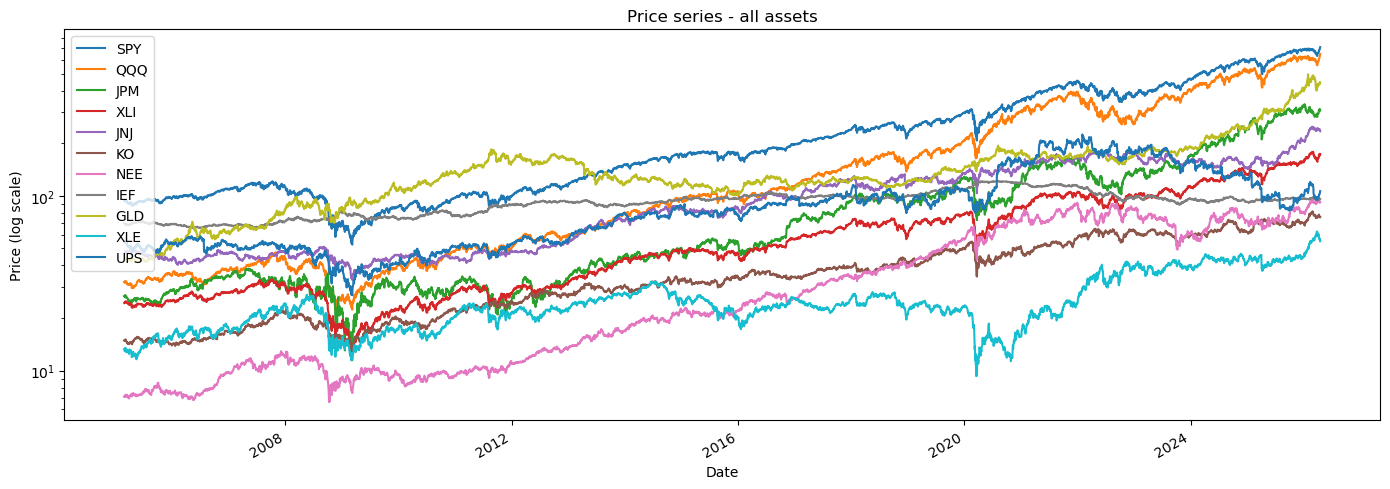

In [11]:
os.makedirs('outputs/01_data_collection', exist_ok=True)

ax = prices.plot(figsize=(14, 5), title='Price series - all assets', logy=True)
ax.set_ylabel("Price (log scale)")
plt.tight_layout()
plt.savefig('outputs/01_data_collection/01_universe_price_panel_quality_check.png', dpi=150)
plt.show()

In [12]:
# Final quality summary
quality_summary = pd.DataFrame({
    "missing_values": subset.isna().sum(),
    "extreme_return_days": extreme_mask.sum(),
    "split_like_days": split_mask.sum()
}).sort_index()

quality_summary.loc["TOTAL"] = [
    quality_summary["missing_values"].sum(),
    quality_summary["extreme_return_days"].sum(),
    quality_summary["split_like_days"].sum()
]

quality_summary

,missing_values,extreme_return_days,split_like_days
GLD,1,0,0
IEF,1,0,0
JNJ,0,0,0
JPM,0,0,0
KO,0,0,0
NEE,1,0,0
QQQ,0,0,0
SPY,1,0,0
UPS,0,0,0
XLE,1,0,0


In [14]:
os.makedirs('data/processed', exist_ok=True)

prices.to_csv("data/processed/prices_clean.csv")
print("Saved prices_clean.csv:", prices.shape)

Saved prices_clean.csv: (5318, 11)


Part B 

VIX AND MOVE INDEXES

In [16]:
VIX_PATH  = "data/raw/VIX_History.csv"
MOVE_PATH = "data/raw/MOVE_History.csv"

#  VIX 
vix = pd.read_csv(VIX_PATH)
vix.columns = [c.strip().upper() for c in vix.columns]

vix = vix.rename(columns={
    "DATE": "Date",
    "CLOSE": "VIX"
})

vix["Date"] = pd.to_datetime(vix["Date"], errors="coerce")
vix["VIX"]  = pd.to_numeric(vix["VIX"], errors="coerce")

vix = (
    vix[["Date", "VIX"]]
    .dropna()
    .drop_duplicates(subset="Date")
    .sort_values("Date")
    .set_index("Date")
)

#  MOVE 
move = pd.read_csv(MOVE_PATH)
move.columns = [c.strip() for c in move.columns]

move = move.rename(columns={
    "Date": "Date",
    "Price": "MOVE"
})

move["Date"] = pd.to_datetime(move["Date"], errors="coerce")
move["MOVE"] = pd.to_numeric(move["MOVE"], errors="coerce")

move = (
    move[["Date", "MOVE"]]
    .dropna()
    .drop_duplicates(subset="Date")
    .sort_values("Date")
    .set_index("Date")
)

print("VIX loaded :", vix.shape,  "|", vix.index.min().date(),  "->", vix.index.max().date())
print("MOVE loaded:", move.shape, "|", move.index.min().date(), "->", move.index.max().date())

VIX loaded : (9166, 1) | 1990-01-02 -> 2026-04-17
MOVE loaded: (5280, 1) | 2005-01-03 -> 2026-04-17


In [17]:
signals_raw = pd.concat([vix, move], axis=1).sort_index()

print("signals_raw shape:", signals_raw.shape)
print("signals_raw date range:", signals_raw.index.min().date(), "->", signals_raw.index.max().date())
print("\nMissing values per column:")
print(signals_raw.isna().sum())

signals_qc = pd.DataFrame({
    "first_date": signals_raw.apply(lambda s: s.first_valid_index()),
    "last_date": signals_raw.apply(lambda s: s.last_valid_index()),
    "missing_count": signals_raw.isna().sum(),
    "missing_pct": (signals_raw.isna().mean() * 100).round(2)
})

display(signals_qc)

signals_raw shape: (9182, 2)
signals_raw date range: 1990-01-02 -> 2026-04-17

Missing values per column:
VIX       16
MOVE    3902
dtype: int64


C:\Users\Georg\AppData\Local\Temp\ipykernel_19696\2966241970.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  signals_raw = pd.concat([vix, move], axis=1).sort_index()


,first_date,last_date,missing_count,missing_pct
VIX,1990-01-02,2026-04-17,16,0.17
MOVE,2005-01-03,2026-04-17,3902,42.50


In [ ]:
# If your universe dataframe is called prices_clean, replace prices with prices_clean
signals = signals_raw.reindex(prices.index).ffill()

# Remove any leading rows that still have NaN after alignment
signals = signals.dropna(how="any")

# Keep only common dates between prices and signals
prices_aligned = prices.loc[signals.index].copy()

print("prices_aligned shape :", prices_aligned.shape)
print("signals shape        :", signals.shape)
print("Common date range    :", signals.index.min().date(), "->", signals.index.max().date())
print("Remaining signal NaN :", signals.isna().sum().sum())

In [ ]:
master_panel = pd.concat([prices_aligned, signals], axis=1)

assert master_panel.index.is_monotonic_increasing
assert signals.isna().sum().sum() == 0
assert set(["VIX", "MOVE"]).issubset(master_panel.columns)

signals.to_csv("data/processed/signals.csv")
master_panel.to_csv("data/processed/master_prices_with_signals.csv")

print("master_panel shape:", master_panel.shape)
print("Saved: data/processed/signals.csv")
print("Saved: data/processed/master_prices_with_signals.csv")

display(master_panel.head())

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

signals["VIX"].plot(ax=axes[0], title="VIX — Aligned Signal", color="tab:red")
axes[0].set_ylabel("Level")
axes[0].grid(True, alpha=0.3)

signals["MOVE"].plot(ax=axes[1], title="MOVE — Aligned Signal", color="tab:blue")
axes[1].set_ylabel("Level")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/signals_overview.png", dpi=150)
plt.show()

print("Saved: data/processed/signals_overview.png")